In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#Carga de datos saltando la fila de título del informe
# Usamos skiprows=1 porque los CSVs tienen una fila vacía/título arriba
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

#Función de limpieza
def limpiar_nombres_columnas(df):
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace('¿', '')
                  .str.replace('?', '')
                  .str.replace('.', '')
                  .str.replace('á', 'a')
                  .str.replace('é', 'e')
                  .str.replace('í', 'i')
                  .str.replace('ó', 'o')
                  .str.replace('ú', 'u'))
    return df

df_ventas = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

#Verificación rápida
print("Columnas en Ventas:", df_ventas.columns.tolist())
print("Columnas en Reservas:", df_reservas.columns.tolist())

Columnas en Ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'codigo_postal_de_tarjeta_de_credito', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'email']
Columnas en Reservas: ['mes_de_la_disponibilidad', 'producto', 'id_de_reserva', 'reprogramacion', 'email', 'nº_de_pax', 'cargos_de_gestion', 'total_pagado_tras_cargos_de_procesamiento']


In [3]:
#ANONIMIZACIÓN
# email -> cliente_id (entero) | CP -> cp_provincia (2 dígitos)
import sys
sys.path.insert(0, '../utils')
from funciones import anonimizar

df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'cliente_id', 'cp_provincia']


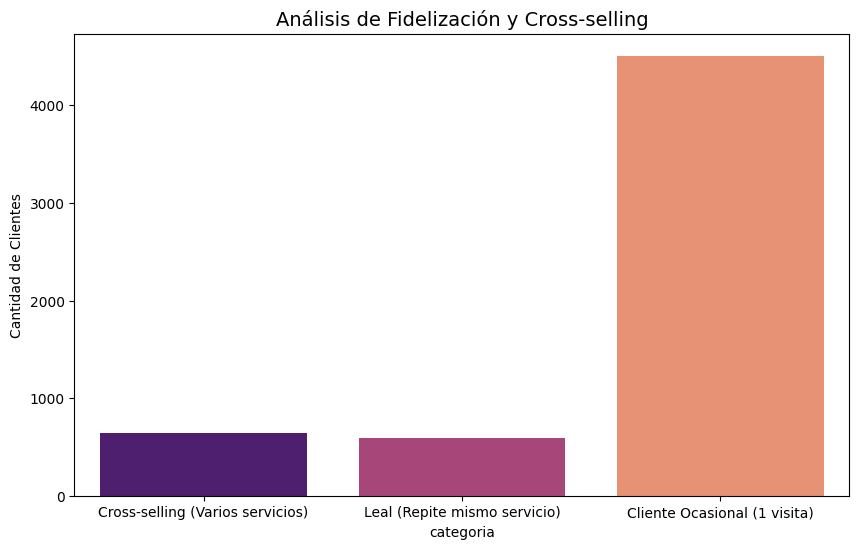

In [4]:
#Crear el perfil del cliente
perfil_cliente = df_ventas.groupby('cliente_id').agg({
    'producto': 'nunique',  # Variedad de servicios probados
    'neto': 'count'         # Frecuencia de visitas
}).rename(columns={'producto': 'servicios_distintos', 'neto': 'visitas_totales'})

#Definir lógica de comportamiento
def definir_perfil(row):
    if row['visitas_totales'] > 1:
        return 'Cross-selling (Varios servicios)' if row['servicios_distintos'] > 1 else 'Leal (Repite mismo servicio)'
    return 'Cliente Ocasional (1 visita)'

perfil_cliente['categoria'] = perfil_cliente.apply(definir_perfil, axis=1)

#Visualización del embudo de retención
plt.figure(figsize=(10, 6))
sns.countplot(data=perfil_cliente, x='categoria', palette='magma', hue='categoria', legend=False)
plt.title('Análisis de Fidelización y Cross-selling', fontsize=14)
plt.ylabel('Cantidad de Clientes')
plt.savefig('../img/04_analisis_retencion.png')
plt.show()